# 03 · Fine-tuning a smaller extractor

The brief's glossary calls out **fine-tuning** and **quantisation**. This notebook reports the run in `finetune/`:

1. The synthetic multilingual dataset (labels made by code)
2. LoRA fine-tune of **Qwen2.5-0.5B-Instruct** on a laptop CPU
3. Export to **GGUF q8_0** and registration with Ollama as `coop-extract`
4. Evaluation against the un-tuned 0.5B and the 3B model used today

Re-run the steps with the commands in `finetune/README.md`. This notebook only reads their outputs, except for the optional evaluation cell.

In [1]:
import json, os, pathlib, time, warnings
import pandas as pd
warnings.filterwarnings("ignore")
if pathlib.Path.cwd().name == "notebooks":
    os.chdir("..")
os.environ.pop("ELEVENLABS_API_KEY", None)  # local Piper voice only: these notebooks demonstrate the offline core
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

import glob
import urllib.request
import matplotlib.pyplot as plt

## 1. Dataset

In [2]:
data = {split: [json.loads(line) for line in open(f"finetune/data/{split}.jsonl", encoding="utf-8")]
        for split in ("train", "eval")}
counts = pd.DataFrame([{"split": s, "task": r["task"]} for s, rows in data.items() for r in rows])
display(counts.value_counts().unstack(fill_value=0))
for r in [r for r in data["train"] if r["task"] == "extract"][:4] + [r for r in data["train"] if r["task"] == "qa"][:2]:
    user = r["messages"][1]["content"].replace("\n", " ")
    print(f"[{r['task']}] {user[:110]}\n      -> {r['messages'][2]['content'][:150]}\n")

task,extract,qa
split,,
train,215,25
eval,37,6


[extract] Wanunuzi wanalipa shilingi 220 kwa kilo ya matunda ya kahawa huko Kiambu.
      -> {"intent": "PRICE_CHECK", "quote": 220, "currency": "KES", "unit": "kg", "product_form": "cherry", "grade": null, "district": "Kiambu"}

[extract] 买家给Nyeri的B级羊皮纸咖啡豆每公斤出价210先令。
      -> {"intent": "PRICE_CHECK", "quote": 210, "currency": "KES", "unit": "kg", "product_form": "parchment", "grade": "B", "district": "Nyeri"}

[extract] A trader wants to pay 95 per kilo for my cherry here in Kiambu.
      -> {"intent": "PRICE_CHECK", "quote": 95, "currency": null, "unit": "kg", "product_form": "cherry", "grade": null, "district": "Kiambu"}

[extract] 在Murang'a，商人给咖啡鲜果每公斤60先令，合理吗？
      -> {"intent": "PRICE_CHECK", "quote": 60, "currency": "KES", "unit": "kg", "product_form": "cherry", "grade": null, "district": "Murang'a"}

[qa] Caller: How much is a bag of fertiliser?  (Write the answer in English.)
      -> {"answer": "", "found": false}

[qa] Caller: Do you sell tractors?  (Write the answer in Eng

## 2. Training run (LoRA, CPU)

,value
base,Qwen/Qwen2.5-0.5B-Instruct
out,finetune/outputs/qwen2.5-0.5b-extract-lora
task,extract
epochs,1
lr,0.0003
batch,4
grad_accum,2
max_len,1024
r,16
alpha,32


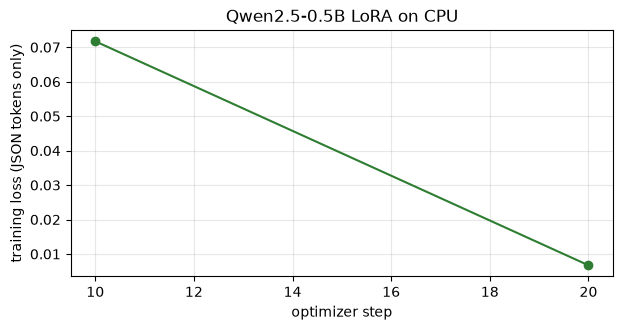

In [3]:
cfg = json.load(open("finetune/configs/qwen2.5-0.5b-extract-cpu.json"))
display(pd.Series(cfg, name="value").to_frame())
states = sorted(glob.glob(cfg["out"] + "/checkpoint-*/trainer_state.json"))
if not states:
    print("No training run found. Run: python finetune/train_lora.py --config finetune/configs/qwen2.5-0.5b-extract-cpu.json")
else:
    log = json.load(open(states[-1]))["log_history"]
    steps = [(e["step"], e["loss"]) for e in log if "loss" in e]
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.plot(*zip(*steps), marker="o", color="#2e7d32")
    ax.set_xlabel("optimizer step"); ax.set_ylabel("training loss (JSON tokens only)")
    ax.set_title("Qwen2.5-0.5B LoRA on CPU"); ax.grid(alpha=0.3)
    plt.show()
    final = [e for e in log if "train_runtime" in e]
    if final:
        print(f"runtime {final[-1]['train_runtime'] / 60:.1f} min, mean train loss {final[-1]['train_loss']:.3f}")

## 3. Export: GGUF and Ollama

In [4]:
for g in glob.glob("finetune/outputs/**/*.gguf", recursive=True):
    print(f"{g}: {pathlib.Path(g).stat().st_size / 1e6:.0f} MB")
tags = json.load(urllib.request.urlopen("http://localhost:11434/api/tags"))["models"]
pd.DataFrame([{"model": m["name"], "size_GB": round(m["size"] / 1e9, 2),
               "quantization": m["details"].get("quantization_level"), "params": m["details"].get("parameter_size")}
              for m in tags])

finetune/outputs\qwen2.5-0.5b-extract-lora\coop-extract-q8_0.gguf: 531 MB


,model,size_GB,quantization,params
0,coop-extract:latest,0.53,Q8_0,494.03M
1,qwen2.5:0.5b,0.40,Q4_K_M,494.03M
2,gemma3:4b,3.34,Q4_K_M,4.3B
3,qwen2.5:3b,1.93,Q4_K_M,3.1B


## 4. Evaluation on the 37 held-out extraction rows

Same prompts, same JSON schema, same normalisation as the app. Exact match means all six slots and the intent are right.

,intent_acc,exact_match,avg_seconds
model,,,
qwen2.5:0.5b,0.946,0.568,3.4
coop-extract,0.973,0.946,3.3
qwen2.5:3b,1.000,0.811,9.9


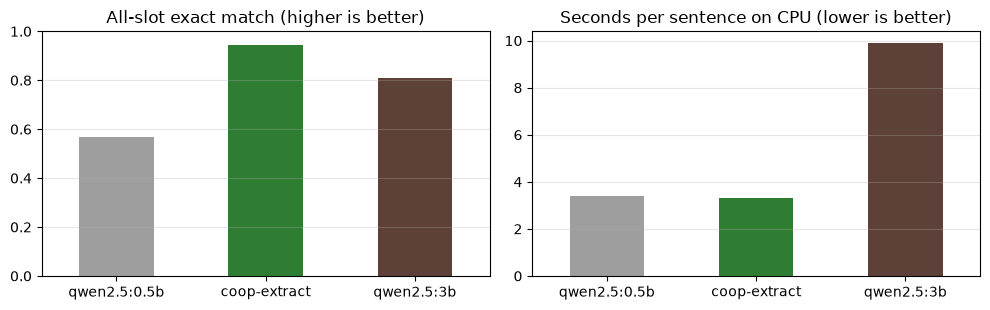

In [5]:
RUN_EVAL = False  # set True to re-run evaluate.py for all three models (a few minutes)
models = ["qwen2.5:0.5b", "coop-extract", "qwen2.5:3b"]
if RUN_EVAL:
    import subprocess, sys
    for m in models:
        subprocess.run([sys.executable, "finetune/evaluate.py", "--task", "extract", "--extract-model", m], check=True)

rows = []
for m in models:
    path = pathlib.Path("finetune/results") / f"extract__{m}__gemma3:4b.json".replace(":", "-")
    if path.exists():
        r = json.load(open(path, encoding="utf-8"))["report"]
        rows.append({"model": m, "intent_acc": r["extract_intent_accuracy"],
                     "exact_match": r["extract_exact_match"], "avg_seconds": r["extract_avg_seconds"]})
results = pd.DataFrame(rows).set_index("model")
display(results)

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.2))
results["exact_match"].plot.bar(ax=a, color=["#9e9e9e", "#2e7d32", "#5d4037"], rot=0, ylim=(0, 1),
                                title="All-slot exact match (higher is better)")
results["avg_seconds"].plot.bar(ax=b, color=["#9e9e9e", "#2e7d32", "#5d4037"], rot=0,
                                title="Seconds per sentence on CPU (lower is better)")
for ax in (a, b):
    ax.grid(axis="y", alpha=0.3); ax.set_xlabel("")
plt.tight_layout(); plt.show()